# Лабораторная работа 1. Базовая обработка SAR-изображения
**DE_IP_2024 · Task 1**

Задание:
1. Загрузить изображение в оттенках серого.
2. Построить гистограмму.
3. Реализовать гамма-коррекцию с параметром γ < 1 и γ > 1.
4. Сравнить исходное и скорректированное изображения по MSE и SSIM.
5. Реализовать алгоритм статистической цветокоррекции на основе статистики `eq_gray`.
6. Протестировать алгоритмы пороговой фильтрации с различными параметрами.

Для каждого решения результат выводится на экран.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

## 1. Загрузка изображения
Изображение читается сразу в оттенках серого (`cv2.IMREAD_GRAYSCALE`), поэтому получается массив `(h, w)` типа `uint8` со значениями 0–255.
При выводе через `imshow` явно задаём `vmin=0, vmax=255`, иначе matplotlib сам растянет контраст и сравнение изображений будет некорректным.

Размер (h, w): (400, 600)
Тип данных   : uint8
Мин / макс   : 0 / 255


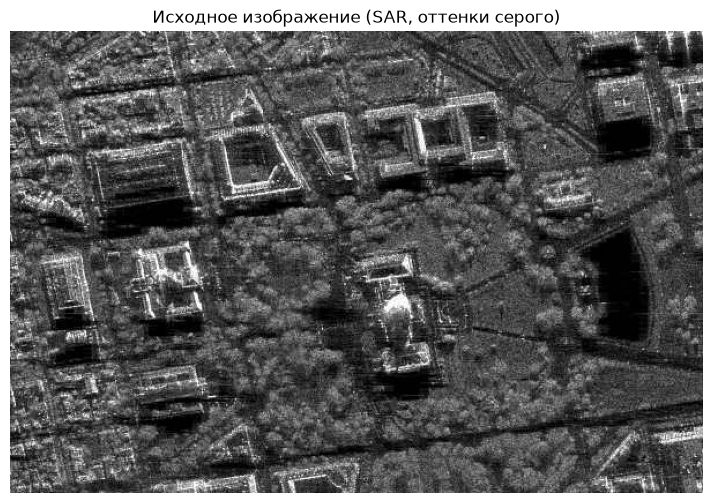

In [2]:
IMAGE_PATH = 'sar_1_gray.png'   # файл лежит в той же папке, что и ноутбук

image_gray = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
assert image_gray is not None, f'Не удалось загрузить {IMAGE_PATH}: проверьте имя файла и папку'

print('Размер (h, w):', image_gray.shape)
print('Тип данных   :', image_gray.dtype)
print('Мин / макс   :', image_gray.min(), '/', image_gray.max())

plt.figure(figsize=(9, 6))
plt.imshow(image_gray, cmap='gray', vmin=0, vmax=255)
plt.title('Исходное изображение (SAR, оттенки серого)')
plt.axis('off')
plt.show()

## 2. Гистограмма
Гистограмма показывает, сколько пикселей имеет каждую из 256 яркостей. Нормируем на число пикселей (получаем доли) и дополнительно строим накопленную гистограмму.

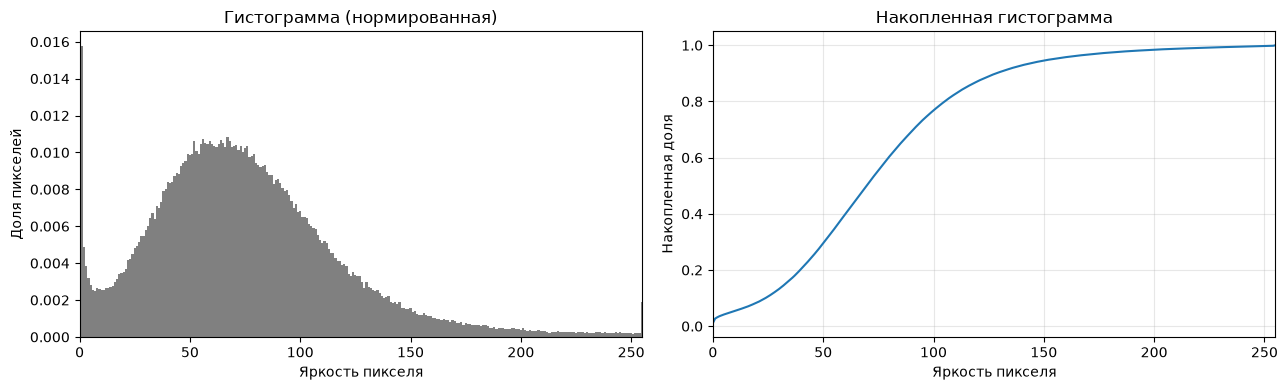

Самая частая яркость       : 1
Средняя яркость            : 74.94
Медиана                    : 70
Стандартное отклонение     : 43.66
Доля тёмных пикселей (<64) : 43.0%


In [3]:
def calc_hist(img):
    """Нормированная гистограмма: доля пикселей для каждой яркости 0..255."""
    h = cv2.calcHist([img], [0], None, [256], (0, 256)).ravel()
    return h / img.size

hist = calc_hist(image_gray)
hist_cum = hist.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(np.arange(256), hist, width=1.0, color='gray')
axes[0].set_title('Гистограмма (нормированная)')
axes[0].set_xlabel('Яркость пикселя')
axes[0].set_ylabel('Доля пикселей')
axes[0].set_xlim(0, 255)

axes[1].plot(hist_cum, color='tab:blue')
axes[1].set_title('Накопленная гистограмма')
axes[1].set_xlabel('Яркость пикселя')
axes[1].set_ylabel('Накопленная доля')
axes[1].set_xlim(0, 255)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Самая частая яркость       : {hist.argmax()}')
print(f'Средняя яркость            : {image_gray.mean():.2f}')
print(f'Медиана                    : {np.median(image_gray):.0f}')
print(f'Стандартное отклонение     : {image_gray.std():.2f}')
print(f'Доля тёмных пикселей (<64) : {hist[:64].sum() * 100:.1f}%')

## 3. Гамма-коррекция
Формула: $s = 255 \cdot (r / 255)^{\gamma}$, где $r$ — исходная яркость, $s$ — новая.

* **γ < 1** — изображение светлеет, растягиваются тёмные тона (видно больше деталей в тенях);
* **γ > 1** — изображение темнеет, растягиваются светлые тона;
* **γ = 1** — изображение не меняется.

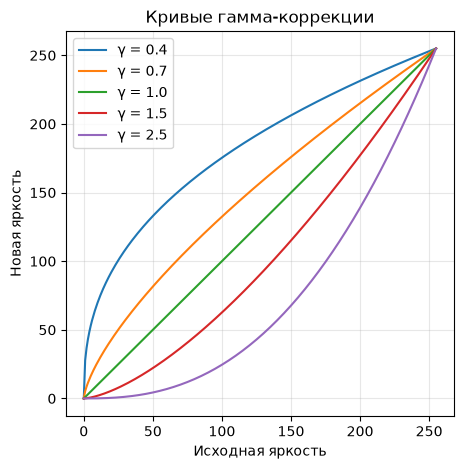

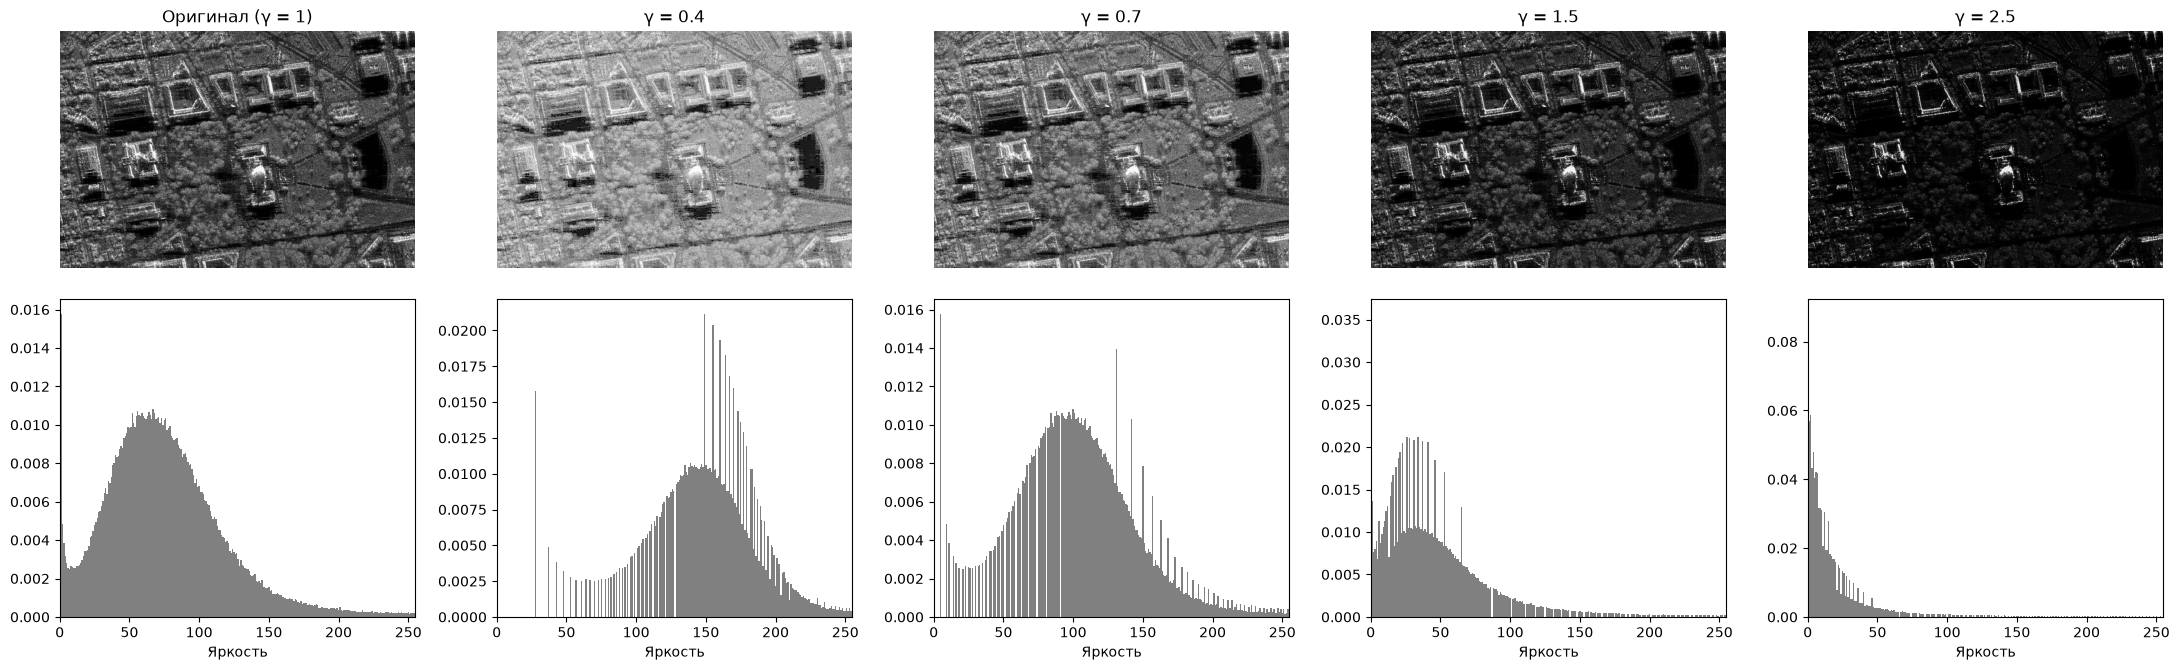

γ = 0.4  | средняя яркость = 148.06 | std =  42.14
γ = 0.7  | средняя яркость = 103.87 | std =  44.91
γ = 1.5  | средняя яркость =  45.69 | std =  39.24
γ = 2.5  | средняя яркость =  20.01 | std =  31.17


In [4]:
def gamma_correction(img, gamma):
    """Гамма-коррекция: s = 255 * (r / 255) ** gamma."""
    normalized = img.astype(np.float64) / 255.0          # приводим к диапазону [0, 1]
    corrected = np.power(normalized, gamma)              # возводим в степень
    return np.clip(np.round(corrected * 255), 0, 255).astype(np.uint8)

gammas = [0.4, 0.7, 1.5, 2.5]                            # две γ < 1 и две γ > 1
gamma_images = {g: gamma_correction(image_gray, g) for g in gammas}

# Кривые преобразования яркости
x = np.linspace(0, 1, 256)
plt.figure(figsize=(5, 5))
for g in [0.4, 0.7, 1.0, 1.5, 2.5]:
    plt.plot(x * 255, 255 * x ** g, label=f'γ = {g}')
plt.title('Кривые гамма-коррекции')
plt.xlabel('Исходная яркость')
plt.ylabel('Новая яркость')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Верхний ряд — изображения, нижний — их гистограммы
items = [('Оригинал (γ = 1)', image_gray)] + [(f'γ = {g}', gamma_images[g]) for g in gammas]
fig, axes = plt.subplots(2, len(items), figsize=(4.4 * len(items), 7))
for i, (title, img) in enumerate(items):
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(title)
    axes[0, i].axis('off')
    axes[1, i].bar(np.arange(256), calc_hist(img), width=1.0, color='gray')
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_xlabel('Яркость')
plt.tight_layout()
plt.show()

for g, img in gamma_images.items():
    print(f'γ = {g:<4} | средняя яркость = {img.mean():6.2f} | std = {img.std():6.2f}')

## 4. Сравнение исходного и скорректированного изображений: MSE и SSIM
* **MSE** — средний квадрат разности яркостей. 0 — изображения идентичны, чем больше, тем сильнее различие.
* **SSIM** — структурное сходство. 1 — идентичны, чем ближе к 0, тем сильнее отличаются.

Строка γ = 1.0 — контрольная: сравнение изображения с самим собой должно дать MSE = 0 и SSIM = 1.

Изображение                    MSE      SSIM
--------------------------------------------
γ = 1.0 (контроль)            0.00    1.0000
γ = 0.4                    5596.58    0.7103
γ = 0.7                     886.23    0.9104
γ = 1.5                     945.28    0.8137
γ = 2.5                    3503.88    0.3367


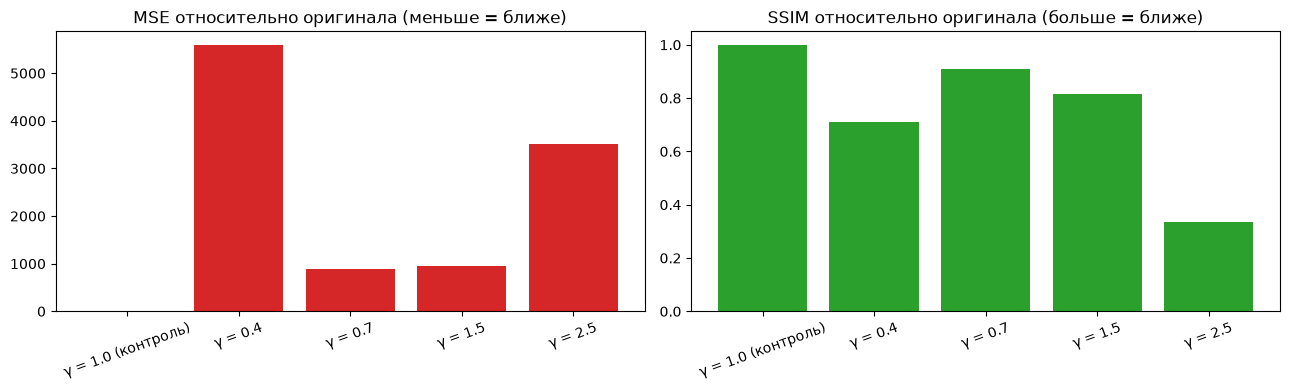

In [5]:
def compare(img_a, img_b):
    """Возвращает (MSE, SSIM) для двух изображений uint8."""
    mse = mean_squared_error(img_a.astype(np.float64), img_b.astype(np.float64))
    ssim = structural_similarity(img_a, img_b, data_range=255)
    return mse, ssim

rows = [('γ = 1.0 (контроль)', image_gray)] + [(f'γ = {g}', gamma_images[g]) for g in gammas]

print(f'{"Изображение":<22}{"MSE":>12}{"SSIM":>10}')
print('-' * 44)
metrics = {}
for name, img in rows:
    mse, ssim = compare(image_gray, img)
    metrics[name] = (mse, ssim)
    print(f'{name:<22}{mse:>12.2f}{ssim:>10.4f}')

names = list(metrics.keys())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(names, [m[0] for m in metrics.values()], color='tab:red')
axes[0].set_title('MSE относительно оригинала (меньше = ближе)')
axes[1].bar(names, [m[1] for m in metrics.values()], color='tab:green')
axes[1].set_title('SSIM относительно оригинала (больше = ближе)')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 5. Статистическая цветокоррекция на основе статистики `eq_gray`
`eq_gray` — результат эквализации гистограммы (`cv2.equalizeHist`). Берём его среднее $\mu_r$ и стандартное отклонение $\sigma_r$ как **эталонную статистику**
и линейно приводим исходное изображение к ней:

$$ out = (src - \mu_s) \cdot \frac{\sigma_r}{\sigma_s} + \mu_r $$

где $\mu_s,\ \sigma_s$ — среднее и СКО исходного изображения. После преобразования значения обрезаются до диапазона [0, 255].

Изображение                      mean      std
----------------------------------------------
Исходное (image_gray)           74.94    43.66
Эталон (eq_gray)               127.03    74.27
После стат. коррекции          123.59    65.27

Обрезано до 0   : 1.12% пикселей
Обрезано до 255 : 5.61% пикселей


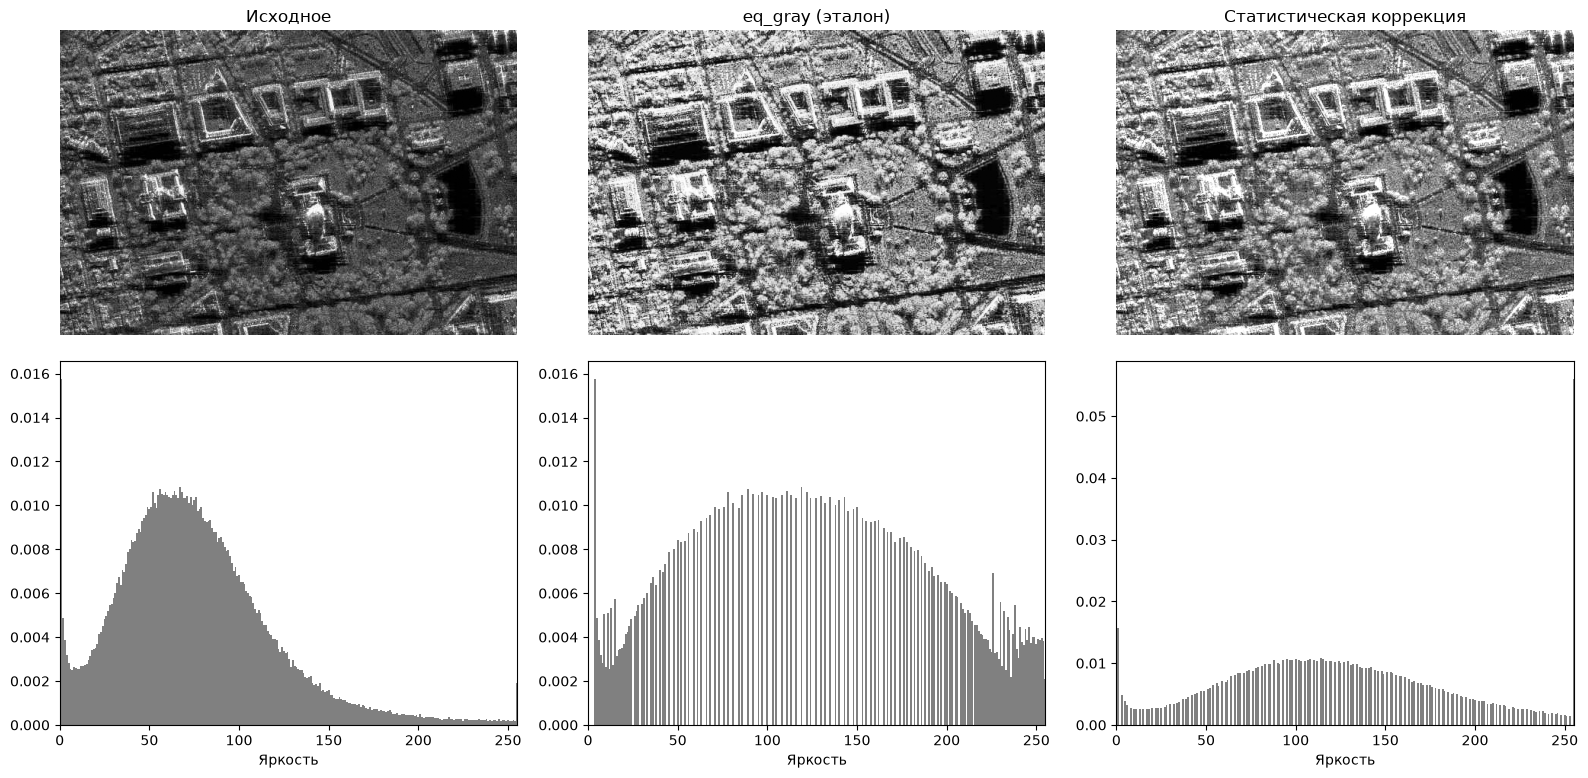


Сравнение                                      MSE      SSIM
------------------------------------------------------------
Исходное  vs  eq_gray                      4021.80    0.6991
Исходное  vs  стат. коррекция              2992.13    0.7841
eq_gray   vs  стат. коррекция               243.84    0.9501


In [6]:
eq_gray = cv2.equalizeHist(image_gray)

def statistical_correction(src, ref):
    """Приводит среднее и СКО изображения src к среднему и СКО эталона ref."""
    src_f = src.astype(np.float64)
    mean_s, std_s = src_f.mean(), src_f.std()
    mean_r, std_r = ref.mean(), ref.std()
    out = (src_f - mean_s) * (std_r / std_s) + mean_r
    return np.clip(np.round(out), 0, 255).astype(np.uint8)

stat_gray = statistical_correction(image_gray, eq_gray)

# Статистика
print(f'{"Изображение":<28}{"mean":>9}{"std":>9}')
print('-' * 46)
for name, img in [('Исходное (image_gray)', image_gray),
                  ('Эталон (eq_gray)', eq_gray),
                  ('После стат. коррекции', stat_gray)]:
    print(f'{name:<28}{img.mean():>9.2f}{img.std():>9.2f}')

# Часть значений после линейного растяжения выходит за [0, 255] и обрезается — из-за этого статистика совпадает с эталоном лишь приблизительно
print(f'\nОбрезано до 0   : {(stat_gray == 0).mean() * 100:.2f}% пикселей')
print(f'Обрезано до 255 : {(stat_gray == 255).mean() * 100:.2f}% пикселей')

# Визуализация
items = [('Исходное', image_gray), ('eq_gray (эталон)', eq_gray), ('Статистическая коррекция', stat_gray)]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (title, img) in enumerate(items):
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(title)
    axes[0, i].axis('off')
    axes[1, i].bar(np.arange(256), calc_hist(img), width=1.0, color='gray')
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_xlabel('Яркость')
plt.tight_layout()
plt.show()

# Метрики
print()
print(f'{"Сравнение":<40}{"MSE":>10}{"SSIM":>10}')
print('-' * 60)
for name, a, b in [('Исходное  vs  eq_gray', image_gray, eq_gray),
                   ('Исходное  vs  стат. коррекция', image_gray, stat_gray),
                   ('eq_gray   vs  стат. коррекция', eq_gray, stat_gray)]:
    mse, ssim = compare(a, b)
    print(f'{name:<40}{mse:>10.2f}{ssim:>10.4f}')

## 6. Пороговая фильтрация
Пороговая фильтрация превращает изображение в бинарное (или обнуляет часть пикселей) по правилу «яркость выше / ниже порога».
Проверяем несколько вариантов: разные значения порога, разные типы порога, автоматический выбор порога (Otsu, Triangle), адаптивный порог.

In [7]:
def show_images(items, rows, cols, cell=(4.5, 3.5)):
    """items — список (заголовок, изображение)."""
    fig, axes = plt.subplots(rows, cols, figsize=(cell[0] * cols, cell[1] * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, img) in zip(axes, items):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    for ax in axes[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def white_percent(img):
    """Доля белых (255) пикселей в процентах."""
    return (img == 255).mean() * 100

### 6.1. Глобальный порог `THRESH_BINARY` при разных значениях порога

T = 50  -> белых пикселей:  70.5%
T = 100 -> белых пикселей:  23.2%
T = 150 -> белых пикселей:   5.5%
T = 200 -> белых пикселей:   1.6%


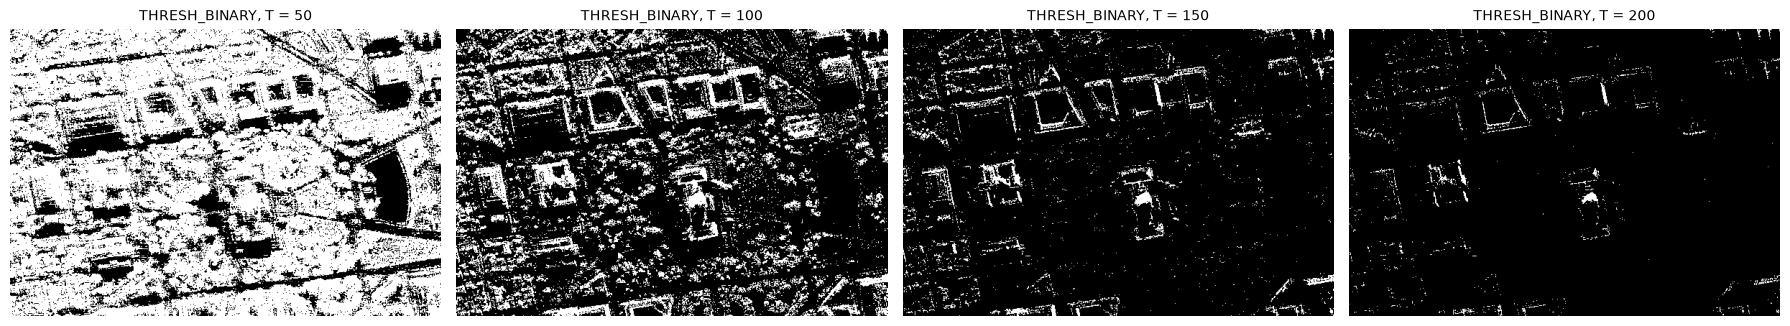

In [8]:
thresholds = [50, 100, 150, 200]
items = []
for t in thresholds:
    _, th = cv2.threshold(image_gray, t, 255, cv2.THRESH_BINARY)
    items.append((f'THRESH_BINARY, T = {t}', th))
    print(f'T = {t:<3} -> белых пикселей: {white_percent(th):5.1f}%')

show_images(items, 1, 4)

### 6.2. Разные типы порога при T = 100

THRESH_BINARY        -> средняя яркость результата:  59.13
THRESH_BINARY_INV    -> средняя яркость результата: 195.87
THRESH_TRUNC         -> средняя яркость результата:  66.75
THRESH_TOZERO        -> средняя яркость результата:  31.38
THRESH_TOZERO_INV    -> средняя яркость результата:  43.56


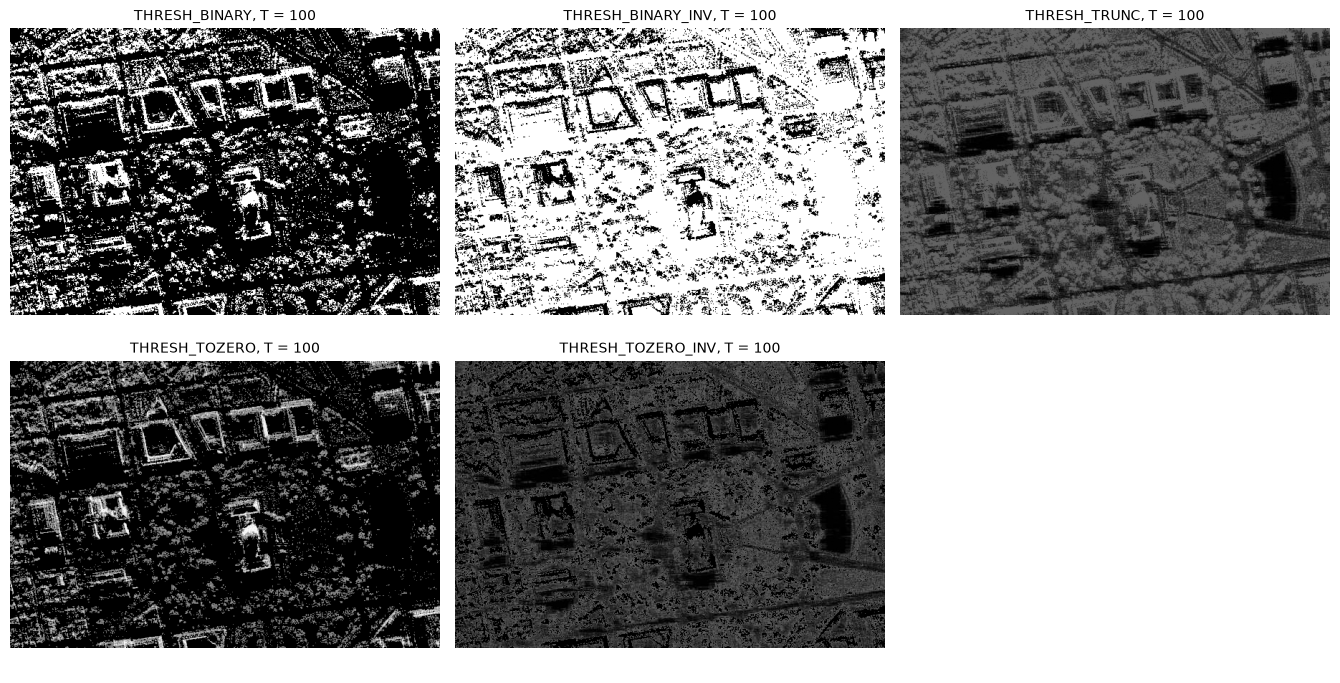

In [9]:
T = 100
types = {
    'THRESH_BINARY':     cv2.THRESH_BINARY,      # >T -> 255, иначе 0
    'THRESH_BINARY_INV': cv2.THRESH_BINARY_INV,  # >T -> 0, иначе 255
    'THRESH_TRUNC':      cv2.THRESH_TRUNC,       # >T -> T, остальное без изменений
    'THRESH_TOZERO':     cv2.THRESH_TOZERO,      # >T без изменений, остальное -> 0
    'THRESH_TOZERO_INV': cv2.THRESH_TOZERO_INV,  # >T -> 0, остальное без изменений
}
items = []
for name, flag in types.items():
    _, th = cv2.threshold(image_gray, T, 255, flag)
    items.append((f'{name}, T = {T}', th))
    print(f'{name:<20} -> средняя яркость результата: {th.mean():6.2f}')

show_images(items, 2, 3)

### 6.3. Автоматический выбор порога: Otsu и Triangle
При использовании `THRESH_OTSU` / `THRESH_TRIANGLE` переданное значение порога игнорируется — OpenCV сам находит порог по гистограмме и возвращает его.

Otsu     : порог = 85, белых пикселей 35.0%
Triangle : порог = 7, белых пикселей 95.3%


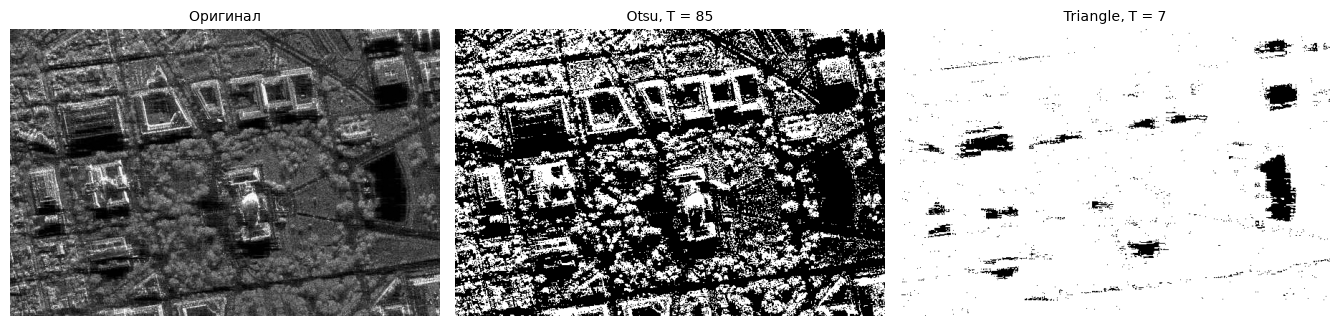

In [10]:
t_otsu, th_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_tri,  th_tri  = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

print(f'Otsu     : порог = {t_otsu:.0f}, белых пикселей {white_percent(th_otsu):.1f}%')
print(f'Triangle : порог = {t_tri:.0f}, белых пикселей {white_percent(th_tri):.1f}%')

show_images([('Оригинал', image_gray),
             (f'Otsu, T = {t_otsu:.0f}', th_otsu),
             (f'Triangle, T = {t_tri:.0f}', th_tri)], 1, 3)

### 6.4. Адаптивный порог
Порог считается для каждого пикселя по его окрестности `blockSize × blockSize`: `ADAPTIVE_THRESH_MEAN_C` — среднее, `ADAPTIVE_THRESH_GAUSSIAN_C` — взвешенное гауссово среднее; из результата вычитается константа `C`.

MEAN_C      blockSize = 11  C = 5 -> белых:  52.5%
MEAN_C      blockSize = 31  C = 5 -> белых:  49.4%
MEAN_C      blockSize = 91  C = 5 -> белых:  49.6%
GAUSSIAN_C  blockSize = 11  C = 5 -> белых:  55.7%
GAUSSIAN_C  blockSize = 31  C = 5 -> белых:  50.7%
GAUSSIAN_C  blockSize = 91  C = 5 -> белых:  49.1%


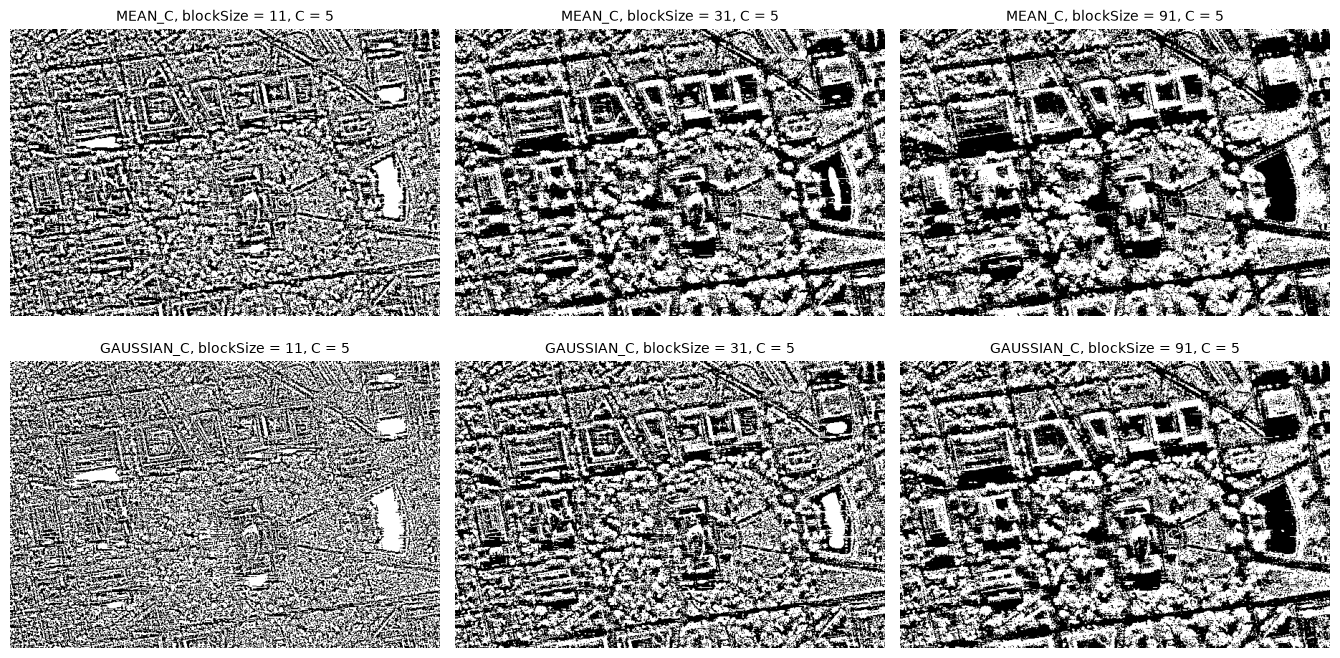


GAUSSIAN_C blockSize = 31 C = 0  -> белых:  42.7%
GAUSSIAN_C blockSize = 31 C = 5  -> белых:  50.7%
GAUSSIAN_C blockSize = 31 C = 15 -> белых:  66.3%


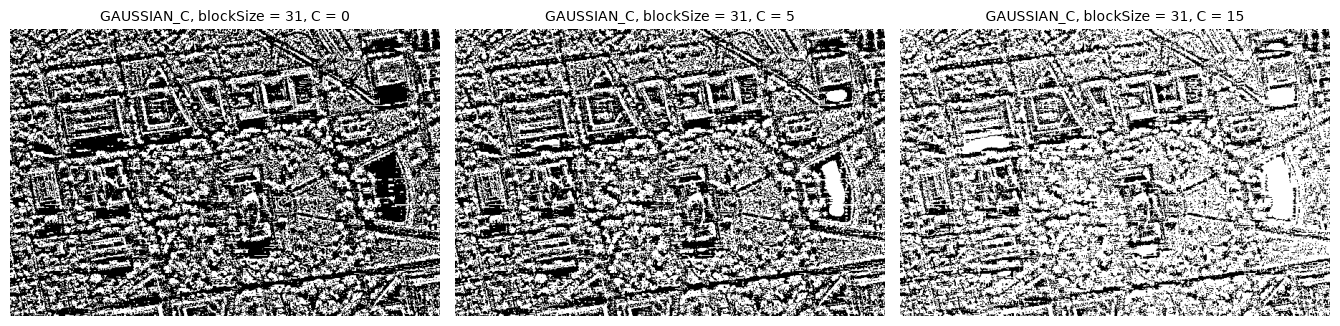

In [11]:
# а) влияние размера окна (C = 5)
methods = {'MEAN_C': cv2.ADAPTIVE_THRESH_MEAN_C, 'GAUSSIAN_C': cv2.ADAPTIVE_THRESH_GAUSSIAN_C}
block_sizes = [11, 31, 91]
items = []
for mname, m in methods.items():
    for bs in block_sizes:
        th = cv2.adaptiveThreshold(image_gray, 255, m, cv2.THRESH_BINARY, bs, 5)
        items.append((f'{mname}, blockSize = {bs}, C = 5', th))
        print(f'{mname:<11} blockSize = {bs:<3} C = 5 -> белых: {white_percent(th):5.1f}%')
show_images(items, 2, 3)

# б) влияние константы C (GAUSSIAN_C, blockSize = 31)
print()
items = []
for c in [0, 5, 15]:
    th = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, c)
    items.append((f'GAUSSIAN_C, blockSize = 31, C = {c}', th))
    print(f'GAUSSIAN_C blockSize = 31 C = {c:<2} -> белых: {white_percent(th):5.1f}%')
show_images(items, 1, 3)

### 6.5. Влияние предварительной обработки на пороговую фильтрацию
Порог T = 127 применяем к исходному изображению, к гамма-скорректированным и к `eq_gray`: от яркости входа результат сильно зависит.

Оригинал   -> белых пикселей:  10.4%
γ = 0.4    -> белых пикселей:  75.3%
γ = 2.5    -> белых пикселей:   1.9%
eq_gray    -> белых пикселей:  49.6%


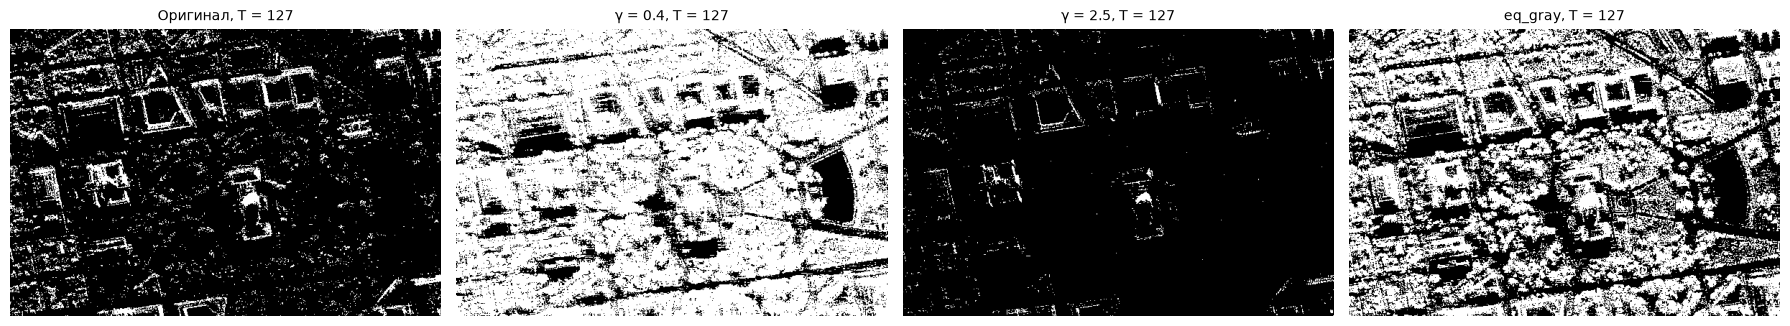

In [12]:
T = 127
candidates = [('Оригинал', image_gray),
              ('γ = 0.4', gamma_images[0.4]),
              ('γ = 2.5', gamma_images[2.5]),
              ('eq_gray', eq_gray)]
items = []
for name, img in candidates:
    _, th = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)
    items.append((f'{name}, T = {T}', th))
    print(f'{name:<10} -> белых пикселей: {white_percent(th):5.1f}%')
show_images(items, 1, 4)

### 6.6. SAR-изображения и спекл-шум
На радарных снимках много зернистого спекл-шума, поэтому порог «в лоб» даёт много мелких артефактов. Попробуем сгладить изображение перед применением Otsu.

Без сглаживания    -> порог Otsu =  85, белых пикселей:  35.0%
medianBlur 5×5     -> порог Otsu =  74, белых пикселей:  46.1%
GaussianBlur 5×5   -> порог Otsu =  79, белых пикселей:  41.9%


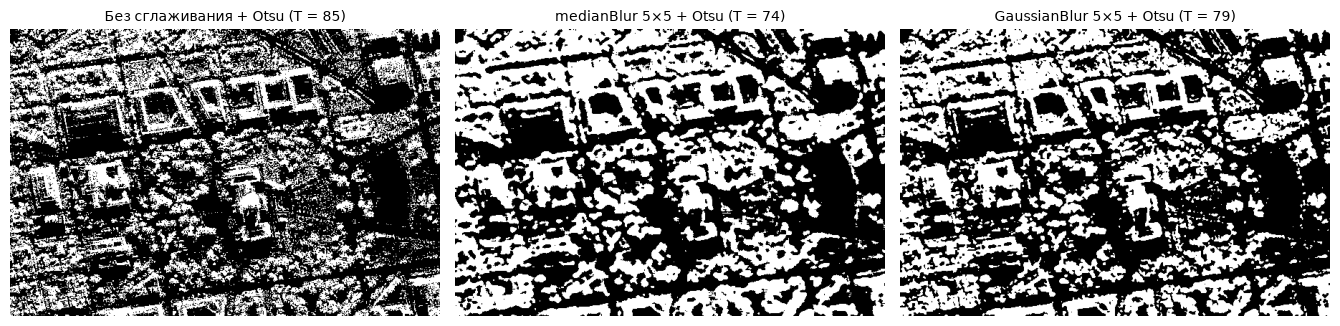

In [13]:
median5 = cv2.medianBlur(image_gray, 5)
gauss5  = cv2.GaussianBlur(image_gray, (5, 5), 0)

items = []
for name, img in [('Без сглаживания', image_gray),
                  ('medianBlur 5×5', median5),
                  ('GaussianBlur 5×5', gauss5)]:
    t, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    items.append((f'{name} + Otsu (T = {t:.0f})', th))
    print(f'{name:<18} -> порог Otsu = {t:3.0f}, белых пикселей: {white_percent(th):5.1f}%')
show_images(items, 1, 3)

## Выводы
1. **Гистограмма.** Изображение тёмное: средняя яркость около 75, около 43% пикселей темнее 64. Самый частый уровень — очень тёмный (радарные тени), яркие пиксели (стены зданий) редки.
2. **Гамма-коррекция.** При γ < 1 изображение светлеет (γ = 0.4: средняя яркость ≈ 148), при γ > 1 темнеет (γ = 2.5: ≈ 20). Чем сильнее γ отличается от 1, тем больше MSE и тем меньше SSIM относительно оригинала; слабая коррекция (γ = 0.7) сохраняет структуру лучше всего (SSIM ≈ 0.91), а γ = 2.5 разрушает много деталей в тёмных областях (SSIM ≈ 0.34).
3. **Статистическая коррекция.** Среднее и СКО результата приближаются к статистике `eq_gray` (≈ 124 / 65 против ≈ 127 / 74), но совпадают не точно: часть значений после растяжения обрезается до [0, 255]. Форма гистограммы остаётся такой же, как у оригинала (преобразование линейное), в отличие от эквализации, которая выравнивает гистограмму. По SSIM результат ближе к оригиналу, чем сам `eq_gray`.
4. **Пороговая фильтрация.** Результат глобального порога сильно зависит от T (при T = 50 белых ≈ 71%, при T = 200 — ≈ 1.5%). Otsu подобрал осмысленный порог (≈ 85), а Triangle выбрал очень низкий (≈ 7) из-за резкого пика гистограммы в области теней, и почти всё изображение стало белым. Адаптивный порог выделяет локальные детали, но на зернистом SAR-снимке даёт много шумовых пикселей. Предварительное сглаживание (медианный или гауссов фильтр) уменьшает влияние спекл-шума.